# Procedural Fractals in 2D, 3D, and 4D

Procedural geometry across scales, from a one-line recurrence:

1. **2D escape-time** — the Mandelbrot/Julia sets, $z\mapsto z^2+c$, and a macro→micro zoom showing
   self-similarity (engineering across scales)
2. **4D** — the **quaternion** Julia set, the same map over $\mathbb H$, rendered as 3-D slices
3. **vector IFS** — iterated function systems (Barnsley fern, Sierpinski, dragon): affine maps, pure
   vector geometry
4. **fractal dimension** by box-counting, reported with honest **significant figures**
5. the bridge back to this repo: a fractal *is* a $1/f$ spatial-frequency spectrum — the
   procedural terrain of `procedural_spatial_frequency_graveyard_3d` was a fractal all along.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

## §1 The escape-time set: $z \mapsto z^2 + c$

For each complex $c$, iterate $z_{n+1}=z_n^2+c$ from $z_0=0$; $c$ is in the Mandelbrot set if the
orbit stays bounded. Smooth (continuous) coloring uses $\nu = n+1-\log_2\log|z|$ so the bands don't
quantize — the "color" of a point encodes *how fast* it escapes.

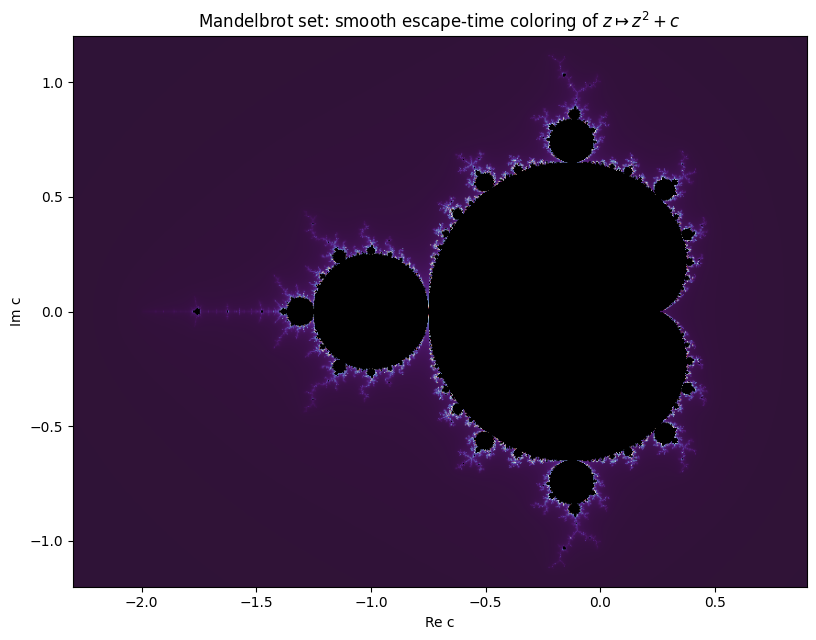

In [2]:
def escape_counts(C, n_iter=256, R=1000.0):
    Z = np.zeros_like(C)
    nu = np.zeros(C.shape, float)
    alive = np.ones(C.shape, bool)
    for n in range(n_iter):
        Z[alive] = Z[alive]**2 + C[alive]
        esc = alive & (np.abs(Z) > R)
        zmag = np.abs(Z[esc])
        nu[esc] = n + 1 - np.log2(np.maximum(np.log(zmag), 1e-12))
        alive &= ~esc
    nu[alive] = np.nan                       # in-set points
    return nu

W, H = 800, 600
xs = np.linspace(-2.3, 0.9, W); ys = np.linspace(-1.2, 1.2, H)
C = xs[None, :] + 1j*ys[:, None]
nu = escape_counts(C)
plt.figure(figsize=(9, 6.5))
plt.imshow(nu, cmap="twilight_shifted", extent=[-2.3, 0.9, -1.2, 1.2], origin="lower")
plt.gca().set_facecolor("black")
plt.title(r"Mandelbrot set: smooth escape-time coloring of $z\mapsto z^2+c$")
plt.xlabel("Re c"); plt.ylabel("Im c"); plt.tight_layout(); plt.show()

## §2 Macro → micro: self-similarity under zoom

Zoom toward a point on the boundary near a "seahorse" region. Each panel is ~8× deeper; structure
keeps reappearing — the hallmark of a fractal, and why "feature size" is meaningless without a
scale. This is the procedural-detail-at-every-zoom that game/engineering LOD systems chase.

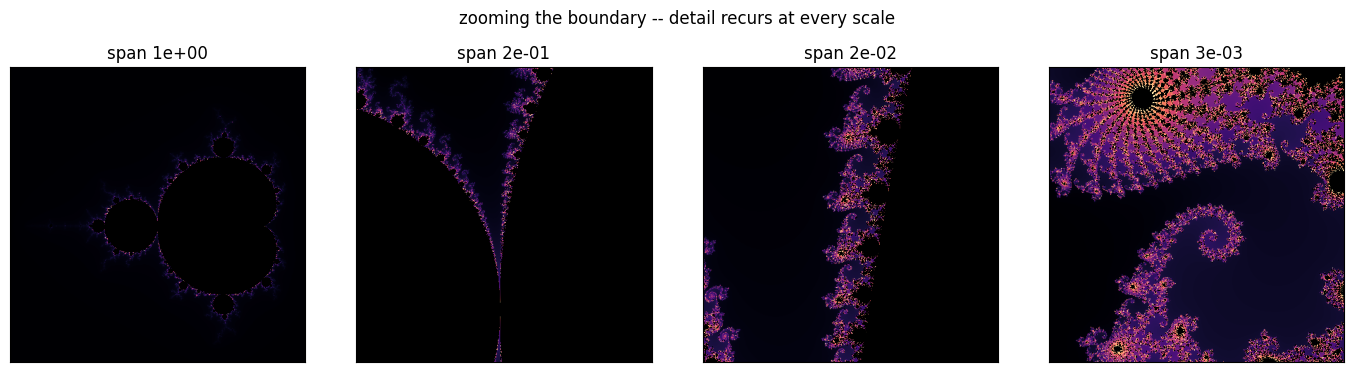

In [3]:
center = -0.745428 + 0.113009j           # a classic boundary point
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
span = 1.4
for ax in axes:
    xs = np.linspace(center.real - span, center.real + span, 420)
    ys = np.linspace(center.imag - span, center.imag + span, 420)
    Cz = xs[None, :] + 1j*ys[:, None]
    nz = escape_counts(Cz, n_iter=400)
    ax.imshow(nz, cmap="magma", extent=[xs[0], xs[-1], ys[0], ys[-1]], origin="lower")
    ax.set_title(f"span {span:.0e}"); ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor("black")
    span /= 8.0
plt.suptitle("zooming the boundary -- detail recurs at every scale", y=1.02)
plt.tight_layout(); plt.show()

## §3 Julia sets: fix $c$, vary the seed

Swap the roles: hold $c$ constant and iterate over the starting point $z_0$. As $c$ crosses the
Mandelbrot boundary the Julia set fractures from a connected blob into "Fatou dust" — a phase
transition in geometry.

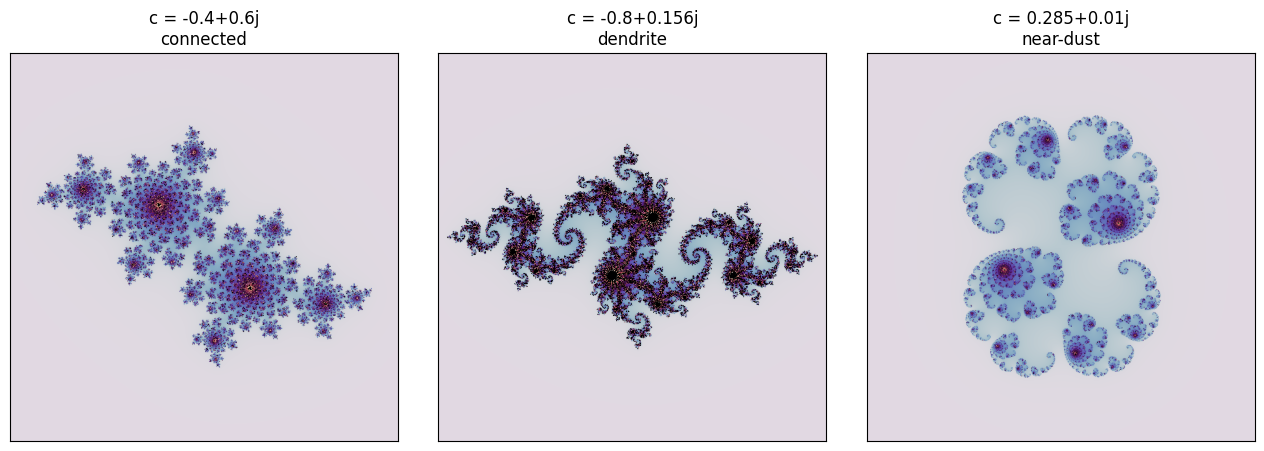

In [4]:
def julia(c, n_iter=256, R=1000.0, res=600, ext=1.6):
    xs = np.linspace(-ext, ext, res); ys = np.linspace(-ext, ext, res)
    Z = xs[None, :] + 1j*ys[:, None]
    nu = np.zeros(Z.shape); alive = np.ones(Z.shape, bool)
    for n in range(n_iter):
        Z[alive] = Z[alive]**2 + c
        esc = alive & (np.abs(Z) > R)
        nu[esc] = n + 1 - np.log2(np.maximum(np.log(np.abs(Z[esc])), 1e-12))
        alive &= ~esc
    nu[alive] = np.nan
    return nu

cs = [(-0.4 + 0.6j, "connected"), (-0.8 + 0.156j, "dendrite"), (0.285 + 0.01j, "near-dust")]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (c, lab) in zip(axes, cs):
    ax.imshow(julia(c), cmap="twilight", origin="lower", extent=[-1.6, 1.6, -1.6, 1.6])
    ax.set_title(f"c = {c:.3g}\n{lab}"); ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor("black")
plt.tight_layout(); plt.show()

## §4 The 4-D fractal: a quaternion Julia set

Run the *same* map $q\mapsto q^2+c$ over the quaternions $\mathbb H$ (a 4-D number system). A
quaternion squares as $q^2=(a^2-|\mathbf v|^2,\;2a\mathbf v)$ for $q=(a,\mathbf v)$. The bounded set
is a 4-D solid; we sweep the fourth coordinate $d$ and render each 3-D slice — a 4-D object shown as
a sequence of 3-D bodies, exactly how §2 of `differential_vs_cumulative` treats a movie as the 4th
axis.

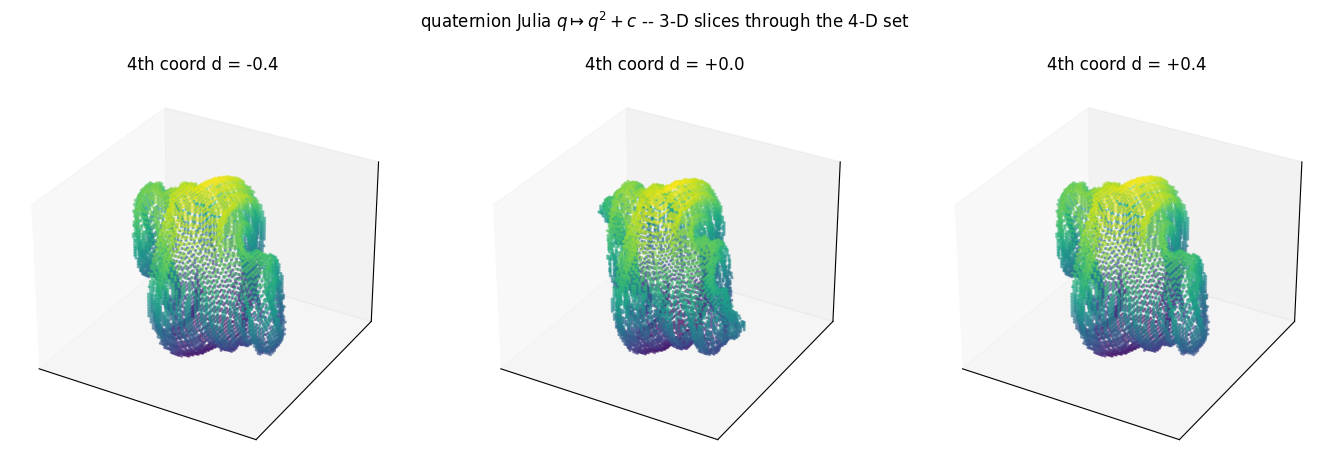

In [5]:
def quaternion_julia_slice(c4, d_slice, n_iter=10, R=2.5, N=84, ext=1.4):
    g = np.linspace(-ext, ext, N)
    A, B, Cc = np.meshgrid(g, g, g, indexing="ij")     # (a, b, c) ; 4th coord d fixed
    D = np.full_like(A, d_slice)
    ca, cb, cc, cd = c4
    alive = np.ones(A.shape, bool)
    for _ in range(n_iter):
        v2 = B*B + Cc*Cc + D*D
        a2 = A*A - v2
        b2 = 2*A*B; c2 = 2*A*Cc; d2 = 2*A*D
        A, B, Cc, D = a2 + ca, b2 + cb, c2 + cc, d2 + cd
        mag = A*A + B*B + Cc*Cc + D*D
        alive &= mag < R*R
        A = np.where(alive, A, 0); B = np.where(alive, B, 0)
        Cc = np.where(alive, Cc, 0); D = np.where(alive, D, 0)
    return g, alive

c4 = (-0.2, 0.6, 0.2, 0.0)                              # a quaternion Julia constant
fig = plt.figure(figsize=(14, 4.6))
for k, ds in enumerate([-0.4, 0.0, 0.4]):
    g, inside = quaternion_julia_slice(c4, ds)
    # keep only surface voxels (bounded with an unbounded neighbour) and subsample
    surf = inside & ~(np.roll(inside, 1, 0) & np.roll(inside, -1, 0) &
                      np.roll(inside, 1, 1) & np.roll(inside, -1, 1) &
                      np.roll(inside, 1, 2) & np.roll(inside, -1, 2))
    idx = np.argwhere(surf)
    if len(idx) > 9000:
        idx = idx[rng.choice(len(idx), 9000, replace=False)]
    ax = fig.add_subplot(1, 3, k+1, projection="3d")
    ax.scatter(g[idx[:, 0]], g[idx[:, 1]], g[idx[:, 2]], c=g[idx[:, 2]],
               cmap="viridis", s=2, alpha=0.5)
    ax.set_title(f"4th coord d = {ds:+.1f}"); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
plt.suptitle(r"quaternion Julia $q\mapsto q^2+c$ -- 3-D slices through the 4-D set", y=1.02)
plt.tight_layout(); plt.show()

## §5 Vector fractals: iterated function systems

No grid, no pixels — just a handful of **affine contraction maps** $\mathbf x\mapsto A\mathbf x+\mathbf b$
applied at random (the chaos game). The attractor is the fractal, defined purely by vectors and
matrices. Barnsley's fern, the Sierpinski triangle, and the Heighway dragon below each come from
2–4 such maps.

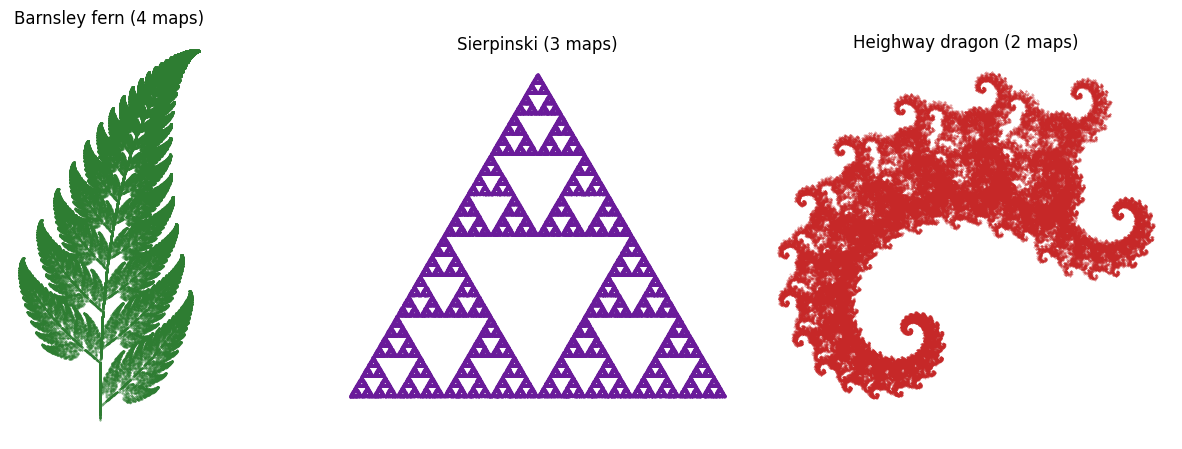

In [6]:
def chaos_game(maps, probs, n=200000, seed=0):
    r = np.random.default_rng(seed)
    pts = np.zeros((n, 2)); xy = np.array([0.0, 0.0])
    choices = r.choice(len(maps), size=n, p=probs)
    for i in range(n):
        A, b = maps[choices[i]]
        xy = A @ xy + b
        pts[i] = xy
    return pts[100:]

fern = ([(np.array([[0, 0], [0, 0.16]]), np.array([0, 0])),
         (np.array([[0.85, 0.04], [-0.04, 0.85]]), np.array([0, 1.6])),
         (np.array([[0.2, -0.26], [0.23, 0.22]]), np.array([0, 1.6])),
         (np.array([[-0.15, 0.28], [0.26, 0.24]]), np.array([0, 0.44]))],
        [0.01, 0.85, 0.07, 0.07])
sierp = ([(np.array([[.5, 0], [0, .5]]), b) for b in
          (np.array([0, 0]), np.array([.5, 0]), np.array([.25, .43]))], [1/3]*3)
dragon = ([(np.array([[.824, -.281], [.281, .824]]), np.array([0, 0])),
           (np.array([[.088, -.52], [.52, .088]]), np.array([.785, .43]))], [0.8, 0.2])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, (maps, probs, col, ttl) in zip(axes, [
        (*fern, "#2e7d32", "Barnsley fern (4 maps)"),
        (*sierp, "#6a1b9a", "Sierpinski (3 maps)"),
        (*dragon, "#c62828", "Heighway dragon (2 maps)")]):
    p = chaos_game(maps, probs)
    ax.scatter(p[:, 0], p[:, 1], s=0.12, c=col, alpha=0.5)
    ax.set_title(ttl); ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

## §6 Fractal dimension by box-counting — with significant figures

Cover the set with boxes of size $\varepsilon$; if $N(\varepsilon)\sim\varepsilon^{-D}$ then the
slope of $\log N$ vs $\log(1/\varepsilon)$ is the box-counting dimension $D$. We measure it for the
Sierpinski gasket (exact $D=\log 3/\log 2$) and report the fit **to the significant figures the fit
actually supports** — the slope's standard error sets the last digit, not the float's 15 digits.

Sierpinski box-counting dimension:
  measured D = 1.579 +/- 0.004   (1 sigma)
  exact      = log3/log2 = 1.585
  -> report as D = 1.579(4)  -- 4 significant figures


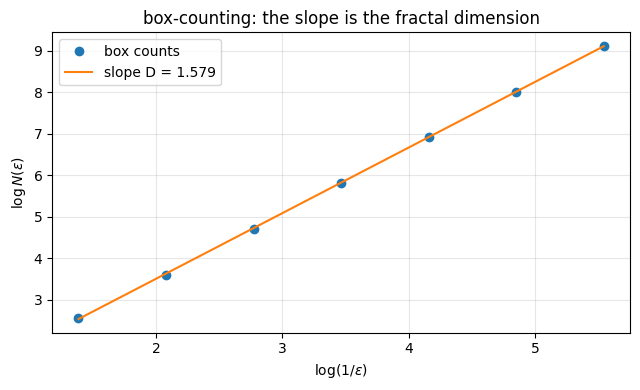

In [7]:
def box_count_dimension(points, sizes=None):
    p = np.asarray(points)
    p = (p - p.min(0)) / (p.max(0) - p.min(0) + 1e-12)    # normalize to unit square
    if sizes is None:
        sizes = [2**k for k in range(2, 9)]               # boxes per side
    loginv, logN = [], []
    for s in sizes:
        idx = np.floor(p * s).astype(int)
        idx = np.clip(idx, 0, s-1)
        filled = len(set(map(tuple, idx)))
        loginv.append(np.log(s)); logN.append(np.log(filled))
    loginv, logN = np.array(loginv), np.array(logN)
    n = len(loginv)
    A = np.vstack([loginv, np.ones(n)]).T
    coef, res, *_ = np.linalg.lstsq(A, logN, rcond=None)
    D = coef[0]
    resid = logN - A @ coef
    se = np.sqrt((resid @ resid) / (n-2) / np.sum((loginv - loginv.mean())**2))
    return D, se, loginv, logN

pts = chaos_game(sierp[0], sierp[1], n=300000)
D, se, li, lN = box_count_dimension(pts)
exact = np.log(3)/np.log(2)
# significant figures: the standard error fixes the last meaningful digit
ndig = max(1, -int(np.floor(np.log10(se))))
print(f"Sierpinski box-counting dimension:")
print(f"  measured D = {D:.{ndig}f} +/- {se:.{ndig}f}   (1 sigma)")
print(f"  exact      = log3/log2 = {exact:.{ndig}f}")
print(f"  -> report as D = {D:.{ndig}f}({round(se*10**ndig)})  -- {ndig+1} significant figures")

plt.figure(figsize=(6.5, 4))
plt.plot(li, lN, "o", label="box counts")
plt.plot(li, D*li + (lN - D*li).mean(), "-", label=f"slope D = {D:.3f}")
plt.xlabel(r"$\log(1/\varepsilon)$"); plt.ylabel(r"$\log N(\varepsilon)$")
plt.title("box-counting: the slope is the fractal dimension"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §7 The bridge: a fractal *is* a $1/f$ spatial-frequency spectrum

Fractional Brownian surfaces — the procedural terrain of the SVG graveyard — have a radially
averaged power spectrum $S(k)\sim k^{-\beta}$. The spectral slope $\beta$ fixes the fractal
dimension: for a 2-D surface $D = 4 - \beta/2$ ... ish (conventions vary), but the *point* is the
clean correspondence **spectral slope $\leftrightarrow$ roughness $\leftrightarrow$ fractal
dimension**. Generate a surface with a chosen slope, measure the slope back from its 2-D FFT.

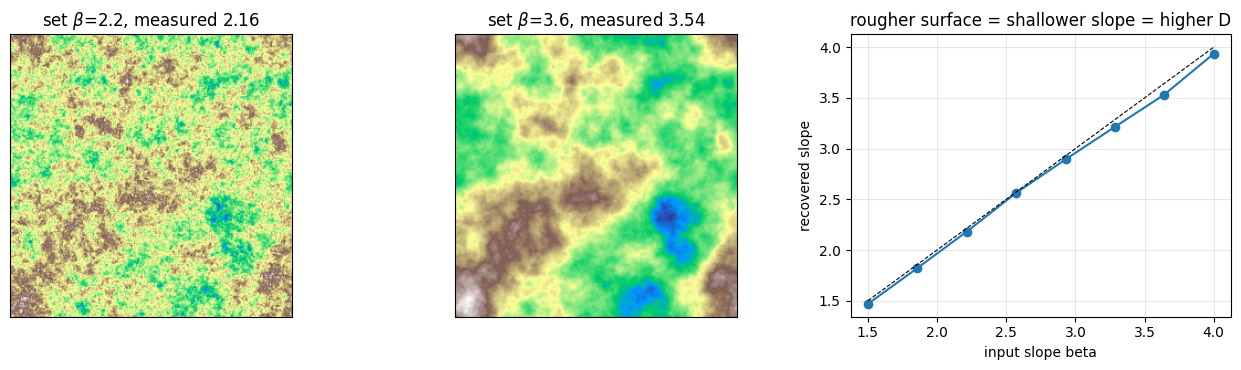

smooth terrain <-> steep 1/f^beta <-> low fractal dimension, and vice-versa.


: 

In [ ]:
def fbm_surface(N=256, beta=3.0, seed=1):
    r = np.random.default_rng(seed)
    kx = np.fft.fftfreq(N)[:, None]; ky = np.fft.fftfreq(N)[None, :]
    k = np.sqrt(kx**2 + ky**2); k[0, 0] = 1.0
    amp = k**(-beta/2)
    phase = np.exp(2j*np.pi*r.random((N, N)))
    field = np.fft.ifft2(amp*phase).real
    return (field - field.mean())/field.std()

def radial_psd_slope(field):
    F = np.abs(np.fft.fftshift(np.fft.fft2(field)))**2
    N = field.shape[0]; c = N//2
    yy, xx = np.indices((N, N))
    rr = np.sqrt((xx-c)**2 + (yy-c)**2).astype(int)
    tbin = np.bincount(rr.ravel(), F.ravel())
    nr = np.bincount(rr.ravel())
    prof = tbin/np.maximum(nr, 1)
    kbin = np.arange(2, c)                       # skip DC and Nyquist
    coef = np.polyfit(np.log(kbin), np.log(prof[kbin]), 1)
    return -coef[0], kbin, prof[kbin]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, beta in zip(axes[:2], [2.2, 3.6]):
    surf = fbm_surface(beta=beta)
    meas, _, _ = radial_psd_slope(surf)
    ax.imshow(surf, cmap="terrain"); ax.set_title(f"set $\\beta$={beta}, measured {meas:.2f}")
    ax.set_xticks([]); ax.set_yticks([])
beta_in = np.linspace(1.5, 4.0, 8)
beta_out = [radial_psd_slope(fbm_surface(beta=b, seed=i))[0] for i, b in enumerate(beta_in)]
axes[2].plot(beta_in, beta_out, "o-"); axes[2].plot(beta_in, beta_in, "k--", lw=0.8)
axes[2].set_xlabel("input slope beta"); axes[2].set_ylabel("recovered slope")
axes[2].set_title("rougher surface = shallower slope = higher D"); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("smooth terrain <-> steep 1/f^beta <-> low fractal dimension, and vice-versa.")

## §8 Summary

| object | dimension | defined by | repo tie |
|---|---|---|---|
| Mandelbrot / Julia | boundary $D=2$ | $z\mapsto z^2+c$ | dynamical iteration |
| quaternion Julia | 4-D solid | $q\mapsto q^2+c$ over $\mathbb H$ | the "4-D as sliced 3-D" view |
| Sierpinski (IFS) | $\log3/\log2\approx1.585$ | affine contraction maps | vector geometry |
| fBm terrain | $D=f(\beta)$ | $1/f^\beta$ spectrum | the procedural-terrain spectrum |

One recurrence, every scale: procedural detail (macro→micro), measured honestly (box-counting with
significant figures), and the same $1/f$ spatial-frequency structure that runs through the optics,
PSD, and procedural-terrain work in this repo.